In [40]:
import pickle
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

def load_data(path: str = "sp500_data.pkl") -> dict:
    with open(path, "rb") as f:
        return pickle.load(f)

C:\Users\PC\AppData\Local\Temp\ipykernel_36892\3896178337.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data['adj_close'].pct_change()


<Axes: title={'center': 'Intraday Return Index'}, xlabel='Date', ylabel='Cumulative Return'>

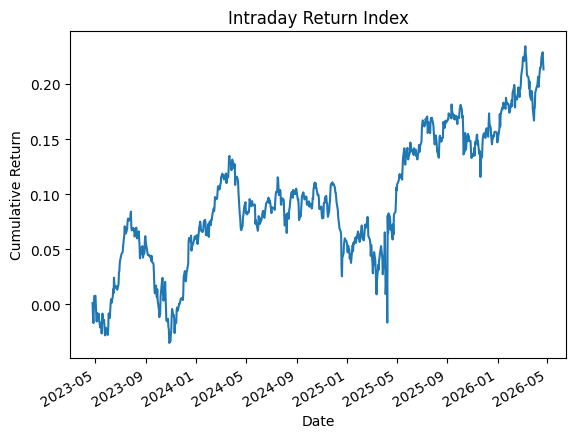

In [2]:
data = load_data()
returns = data['adj_close'].pct_change()
overnight = (data["Open"] - data["Close"].shift(1)) / data["Close"].shift(1)
intraday = data['intraday_returns']
intraday_index = intraday.mean(axis=1)
intraday_index.cumsum().plot(title="Intraday Return Index", ylabel="Cumulative Return")

In [9]:
one_year_momentum = intraday_index.rolling(window=252).sum()
twenty_one_day_momentum = intraday_index.rolling(window=21).sum()
volatility = intraday_index.rolling(window=252).std() * np.sqrt(252)

In [41]:
x = pd.concat([one_year_momentum, twenty_one_day_momentum, volatility], axis=1)
x.columns = ["1Y Momentum", "21D Momentum", "Volatility"]
x = x.shift(1)
target = intraday_index.copy()
target[target > 0] = 1
target[target <= 0] = 0

model = XGBClassifier(
    n_estimators=50, 
    learning_rate=0.1, 
    max_depth=3, 
    objective='binary:logistic'
)

count = 0
for day in x.index:
    if count >= 554:
        insample = x.loc[x.index[count-252]:x.index[count]]
        target = intraday_index.loc[x.index[count-252]:x.index[count]]
        model.fit(insample, target)
        predictions = model.predict(insample)
        break
    count += 1

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 

In [38]:
insample

,1Y Momentum,21D Momentum,Volatility
Date,,,
2024-07-08,0.041009,0.013887,0.096494
2024-07-09,0.039351,0.008981,0.096499
2024-07-10,0.033072,0.009742,0.096376
2024-07-11,0.029069,0.014469,0.096039
2024-07-12,0.027506,0.013896,0.095923
...,...,...,...
2025-07-03,0.071693,0.026180,0.160951
2025-07-07,0.084176,0.020169,0.160666
2025-07-08,0.073436,0.018124,0.160703


In [35]:
insample

,1Y Momentum,21D Momentum,Volatility
Date,,,
2024-07-08,0.041009,0.013887,0.096494
2024-07-09,0.039351,0.008981,0.096499
2024-07-10,0.033072,0.009742,0.096376
2024-07-11,0.029069,0.014469,0.096039
2024-07-12,0.027506,0.013896,0.095923
...,...,...,...
2025-07-03,0.071693,0.026180,0.160951
2025-07-07,0.084176,0.020169,0.160666
2025-07-08,0.073436,0.018124,0.160703


In [26]:
day

Timestamp('2024-04-24 00:00:00')